# Phase 7 : Principal Component Analysis (PCA)

**Objective**

Determine whether dimensionality reduction is appropriate and, if so, transform the feature space while preserving as much information as possible.

**Inputs**
* preprocessed_dataset.csv

**Outputs**
* pca_df<br>
* PCA Report<br>
* Explained Variance Plot<br>
* Component Loading Matrix

**Assumptions**
* Data has already been cleaned.<br>
* Features have been engineered.<br>
* Features have been validated<br>
* Data has been standardized.

**Expected Deliverables**

By the end of this notebook we should know

* Is PCA appropriate?<br>
* How many components should be retained?<br>
* What does each principal component represent?<br>
* How much variance is preserved?

**FACT**

PCA is useful when variables are correlated.

**ASSUMPTION**

Our selected features may share overlapping information.

**HYPOTHESIS**

If moderate-to-high correlations exist, PCA can compress the dataset while preserving most of its information.

**LIMITATION**

PCA finds directions of maximum variance, not necessarily directions of maximum interpretability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed dataset
scaled_df = pd.read_csv("dataset//preprocessed_dataset.csv")

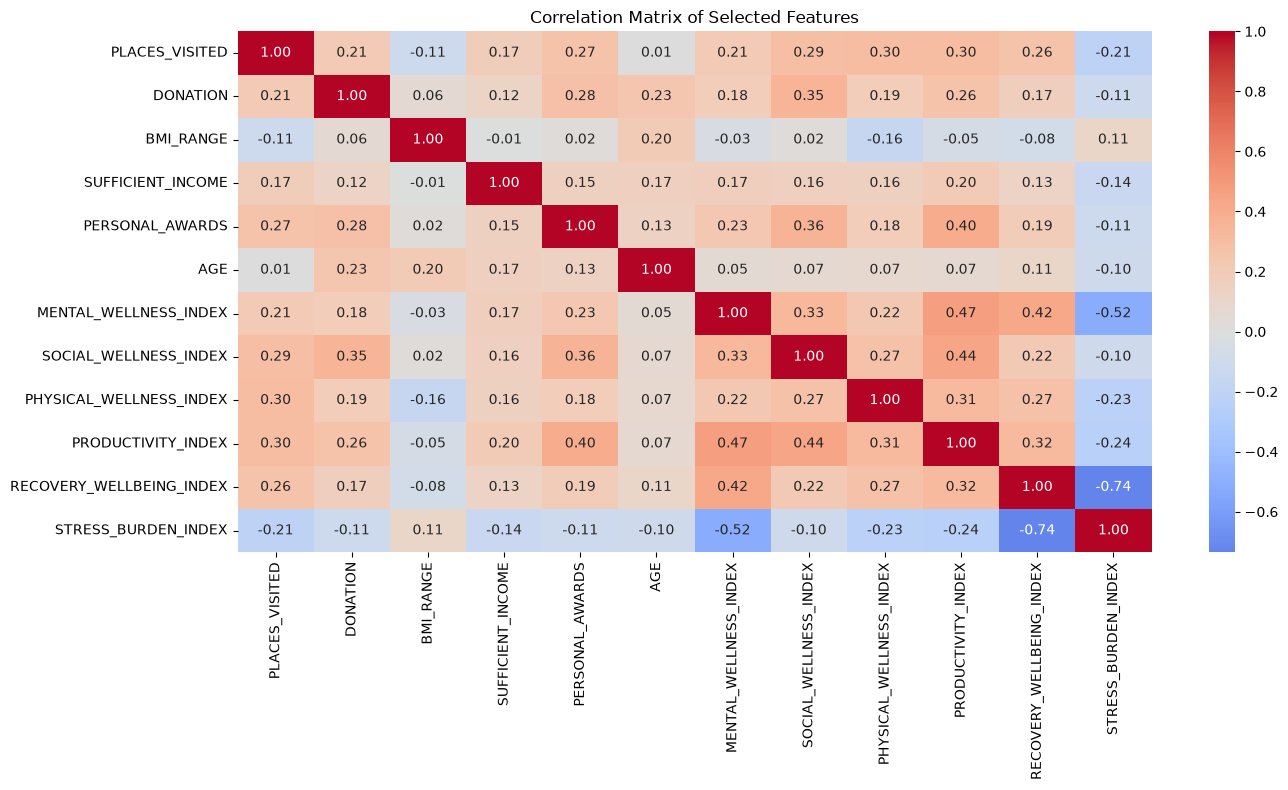

In [3]:
plt.figure(figsize=(14,8))

sns.heatmap(

    scaled_df.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"

)

plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.show()

<h3>Average Correlation</h3>

In [4]:
corr_matrix = scaled_df.corr().abs()

upper_triangle = corr_matrix.where(

    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

)

average_corr = upper_triangle.stack().mean()

print(f"Average Absolute Correlation: {average_corr:.3f}")

Average Absolute Correlation: 0.204


| Average Correlation | Meaning                  |
| ------------------- | ------------------------ |
| <0.20               | PCA probably unnecessary |
| 0.20–0.40           | PCA may help             |
| >0.40               | PCA likely beneficial    |


<h3>Bartlett's Test of Sphericity</h3>

In [5]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(scaled_df)

print(f"Chi-Square Statistic : {chi_square_value:.3f}")
print(f"P-value              : {p_value:.6f}")

Chi-Square Statistic : 41889.394
P-value              : 0.000000


here p value is less than 0.05 so it suggest that the correlation matrix is significantly different from an identity matrix.<br>
There is evidence supporting PCA.

<h3>Kaiser-Meyer-Olkin (KMO) Test<h3>

In [6]:
from factor_analyzer.factor_analyzer import calculate_kmo

kmo_per_feature, kmo_model = calculate_kmo(scaled_df)

print(f"Overall KMO Score : {kmo_model:.3f}")

kmo_table = pd.DataFrame({
    "Feature": scaled_df.columns,
    "KMO Score": kmo_per_feature
})

display(kmo_table.round(3))

Overall KMO Score : 0.763


,Feature,KMO Score
0,PLACES_VISITED,0.871
1,DONATION,0.824
2,BMI_RANGE,0.563
3,SUFFICIENT_INCOME,0.861
4,PERSONAL_AWARDS,0.853
5,AGE,0.598
6,MENTAL_WELLNESS_INDEX,0.783
7,SOCIAL_WELLNESS_INDEX,0.806
8,PHYSICAL_WELLNESS_INDEX,0.867
9,PRODUCTIVITY_INDEX,0.824


| KMO         | Interpretation |
| ----------- | -------------- |
| >0.9        | Excellent      |
| >0.8        | Great          |
| **0.7–0.8** | **Good**       |
| 0.6–0.7     | Fair           |


<h3>Eigenvalue Analysis</h3>

In [7]:
correlation_matrix = scaled_df.corr()

eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

eigen_table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue": eigenvalues
})

display(eigen_table.round(3))

,Principal Component,Eigenvalue
0,PC1,3.438
1,PC2,1.489
2,PC3,1.249
3,PC4,0.226
4,PC5,0.980
5,PC6,0.461
6,PC7,0.866
7,PC8,0.533
8,PC9,0.579
9,PC10,0.755


<h3>PCA</h3>

In [8]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(scaled_df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

<h3>Explained Variance</h3>

In [9]:
explained_variance = pd.DataFrame({

    "Principal Component": [
        f"PC{i+1}"
        for i in range(len(pca.explained_variance_ratio_))
    ],

    "Explained Variance Ratio":
        pca.explained_variance_ratio_,

    "Cumulative Variance":
        np.cumsum(pca.explained_variance_ratio_)

})

display(
    explained_variance.round(4)
)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.2865,0.2865
1,PC2,0.1241,0.4106
2,PC3,0.1041,0.5147
3,PC4,0.0817,0.5964
4,PC5,0.0722,0.6686
5,PC6,0.0629,0.7315
6,PC7,0.0603,0.7917
7,PC8,0.0583,0.8500
8,PC9,0.0482,0.8983
9,PC10,0.0444,0.9427


<h3>Scree Plot</h3>

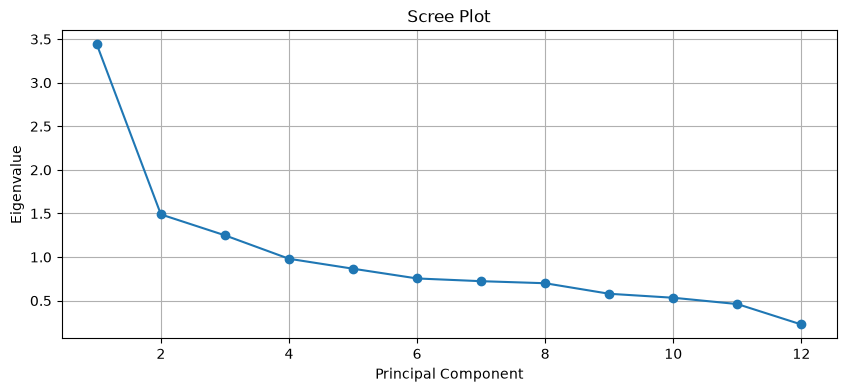

In [10]:
plt.figure(figsize=(10,4))

plt.plot(
    range(1, len(pca.explained_variance_)+1),
    pca.explained_variance_,
    marker='o'
)

plt.xlabel("Principal Component")

plt.ylabel("Eigenvalue")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

Here it can be easily interpreted that just after 1 PC component there is an elbow which suggest that component captures maximum variance latent lifestyle dimension and remaining PCs still contribute meaningful but progressively smaller amounts of information.

# Final Verdict

*Principal Component Analysis was evaluated as a potential dimensionality reduction technique. Bartlett's Test of Sphericity (p < 0.001) and an overall KMO score of 0.763 indicated that the data were suitable for PCA. However, explained variance analysis showed that approximately nine principal components were required to retain 90% of the total variance and ten components were required to retain approximately 95% of the variance. This indicates limited dimensionality reduction. Given the modest compression achieved and the loss of interpretability associated with principal components, the original validated feature set was retained for subsequent clustering analysis.*

**Evidence supporting PCA**

✔ Bartlett significant<br>
✔ KMO = 0.763<br>
✔ Three eigenvalues >1

**Evidence against PCA**

✖ 9 PCs required for ~90% variance<br>
✖ 10 PCs required for ~95% variance<br>
✖ Only modest dimensionality reduction<br>
✖ Principal Components lose interpretability<br>
✖ Original feature space already highly interpretable

**Decision**

Rather than directly replacing the original feature space with principal components, PCA will be treated as an alternative feature representation.

The final decision regarding PCA will be made after comparing clustering performance between:

* Original standardized features.<br>
* PCA-transformed features (3 principal components).

The representation producing better clustering quality and interpretability will be selected for the final model.

In [13]:
# Save Standardized Dataset

scaled_df.to_csv(
    "dataset//scaled_features.csv",
    index=False
)

print("Scaled feature dataset saved successfully.")

Scaled feature dataset saved successfully.


In [14]:
# Create PCA Dataset (3 Components)

pca = PCA(n_components=3)

pca_array = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_array,
    columns=["PC1", "PC2", "PC3"]
)

pca_df.to_csv(
    "dataset//pca_features.csv",
    index=False
)

print("PCA dataset saved successfully.")

display(pca_df.head())

PCA dataset saved successfully.


,PC1,PC2,PC3
0,-2.250030,-0.851620,-0.225671
1,-0.252660,0.350090,1.074253
2,-1.325374,0.710167,1.100192
3,-1.387742,2.660277,0.174119
4,0.550012,0.864304,1.920933
